# 📡 Práctica: Sistemas de Comunicación Clásicos vs. Neuronales (DeepJSCC)

¡Bienvenidos a esta sesión práctica del curso de **Sistemas de Comunicación**!

Tradicionalmente, los sistemas de comunicación se diseñan basándose en el Teorema de Separación de Shannon, el cual establece que la compresión de datos (Codificación de Fuente) y la protección contra errores (Codificación de Canal) pueden diseñarse de manera independiente sin pérdida de optimidad teórica (en el límite de bloques de longitud infinita).

Sin embargo, en escenarios prácticos con latencia estricta o canales variantes, este enfoque presenta limitaciones, como el catastrófico **"efecto acantilado" (cliff effect)** cuando la calidad del canal cae por debajo de la tasa de diseño.

En este notebook, exploraremos cómo el Aprendizaje Profundo (*Deep Learning*) ofrece una alternativa robusta mediante la **Codificación Conjunta Fuente-Canal (JSCC)**.

### 🎯 Objetivos de Aprendizaje

A través de simulaciones con el dataset de imágenes **MNIST**, este laboratorio está dividido en tres fases principales:

1. **Fase 1 | Codificación de Fuente (Compresión):**
   Compararemos la capacidad de reducción de dimensionalidad lineal clásica (Análisis de Componentes Principales - **PCA**) frente a la compresión no lineal utilizando redes neuronales (**Autoencoders**). Analizaremos las curvas teóricas de Tasa-Distorsión.

2. **Fase 2 | Semántica del Espacio Latente:**
   Visualizaremos geométricamente cómo ambos algoritmos organizan la información comprimida en un plano bidimensional ($d=2$), demostrando la superioridad topológica de las representaciones no lineales.

3. **Fase 3 | Transmisión sobre Canal Físico (AWGN) y DeepJSCC:**
   Introduciremos restricciones físicas reales (normalización de potencia) y ruido térmico (Canal AWGN). Evaluaremos la robustez de un Autoencoder entrenado de extremo a extremo (DeepJSCC) frente a un esquema lineal clásico sometido a un barrido de Relación Señal a Ruido (SNR). Demostraremos visual y cuantitativamente la **"degradación suave" (graceful degradation)** del enfoque neuronal.

### 🛠️ Herramientas Utilizadas
* **PyTorch:** Para el diseño, entrenamiento y simulación del Autoencoder y el canal físico.
* **Scikit-Learn:** Para la implementación de la línea base matemática (PCA).
* **Matplotlib:** Para el análisis visual de métricas y señales reconstruidas.

---
*Ejecuta las celdas de forma secuencial. Si estás en Google Colab, asegúrate de activar el entorno de ejecución de GPU para acelerar el entrenamiento (Entorno de ejecución > Cambiar tipo de entorno de ejecución > GPU).*

# Comparación de Codificación de Fuente y JSCC con MNIST

### ¿Qué es el dataset MNIST?
El conjunto de datos **MNIST** (*Modified National Institute of Standards and Technology*) es uno de los estándares más clásicos en el aprendizaje automático y la visión por computadora.

* **Contenido:** Dígitos manuscritos del 0 al 9.
* **Formato:** Imágenes en escala de grises de 28x28 píxeles. Al "aplanar" estas imágenes para su procesamiento secuencial o mediante redes densas, obtenemos vectores de **784 dimensiones**.
* **Tamaño:** 60,000 muestras de entrenamiento y 10,000 muestras de prueba.

En este notebook, utilizamos MNIST porque su simplicidad nos permite visualizar intuitivamente los efectos de la compresión (reducción de dimensionalidad) y la distorsión del canal (ruido AWGN) en la reconstrucción de la señal original.

In [6]:
# ==========================================
# CELDA 1: Importaciones y Preparación de Datos (MNIST)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader
import math

# Configuración del dispositivo (GPU si está disponible para acelerar el entrenamiento)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de cómputo: {device}")

# 1. Preparación del dataset MNIST
# Las imágenes originales son de 28x28 con valores de píxeles entre 0 y 255.
# Aplicamos transformaciones para:
# - Convertir a tensores de PyTorch y escalar los valores a [0.0, 1.0]
# - Aplanar la matriz 2D (28x28) a un vector 1D de 784 características.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x))
])

# Descarga y carga de los conjuntos de entrenamiento (60k) y prueba (10k)
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Extraemos todo el conjunto de datos como tensores para los algoritmos clásicos de Scikit-Learn (PCA)
# Se dividen entre 255.0 para asegurar la normalización en el formato requerido por sklearn
X_train_full = train_dataset.data.view(-1, 784).float() / 255.0
X_test_full = test_dataset.data.view(-1, 784).float() / 255.0
y_test_full = test_dataset.targets.numpy()

print(f"Dimensiones del conjunto de entrenamiento: {X_train_full.shape}")
print(f"Dimensiones del conjunto de prueba: {X_test_full.shape}")

Dispositivo de cómputo: cuda
Dimensiones del conjunto de entrenamiento: torch.Size([60000, 784])
Dimensiones del conjunto de prueba: torch.Size([10000, 784])


Iniciando Fase 1: Entrenamiento y Evaluación de Modelos (PCA vs AE)...

PCA | Dim:  2 | MSE de prueba: 0.055669
AE  | Dim:  2 | MSE de prueba: 0.046395

PCA | Dim:  8 | MSE de prueba: 0.037441
AE  | Dim:  8 | MSE de prueba: 0.022376

PCA | Dim: 16 | MSE de prueba: 0.026860
AE  | Dim: 16 | MSE de prueba: 0.015342

PCA | Dim: 32 | MSE de prueba: 0.016828
AE  | Dim: 32 | MSE de prueba: 0.009601



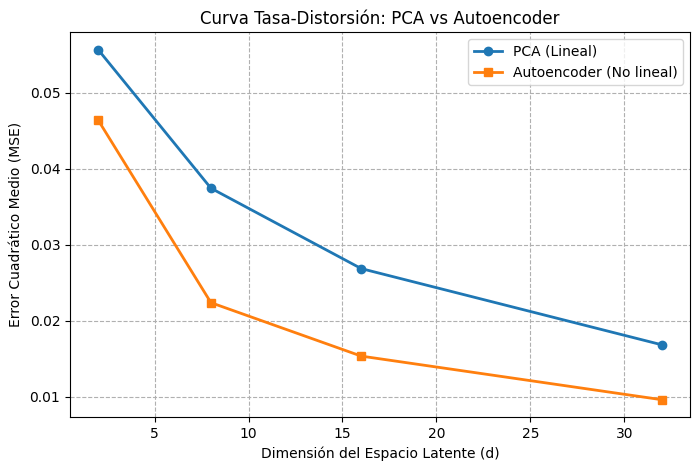

In [7]:
# ==========================================
# CELDA 2: FASE 1 - Entrenamiento PCA y Autoencoders
# ==========================================

# Definición del Autoencoder (Enfoque Neuronal)
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        # Encoder: 784 -> 128 -> d
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        # Decoder: d -> 128 -> 784 -> Sigmoid (para normalizar salida a [0,1])
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

dimensions = [2, 8, 16, 32]
mse_pca = []
mse_ae = []
models_ae = {}
pca_models = {}

print("Iniciando Fase 1: Entrenamiento y Evaluación de Modelos (PCA vs AE)...\n")

for d in dimensions:
    # -------------------------
    # Enfoque Clásico: PCA
    # -------------------------
    pca = PCA(n_components=d)
    X_train_numpy = X_train_full.numpy()
    X_test_numpy = X_test_full.numpy()

    pca.fit(X_train_numpy)
    pca_models[d] = pca

    # Proyectar y reconstruir
    X_test_pca = pca.transform(X_test_numpy)
    X_test_reconstructed = pca.inverse_transform(X_test_pca)

    # Calcular MSE
    mse_p = np.mean((X_test_numpy - X_test_reconstructed)**2)
    mse_pca.append(mse_p)
    print(f"PCA | Dim: {d:2d} | MSE de prueba: {mse_p:.6f}")

    # -------------------------
    # Enfoque Neuronal: Autoencoder
    # -------------------------
    model = Autoencoder(latent_dim=d).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    epochs = 10

    model.train()
    for epoch in range(epochs):
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, data)
            loss.backward()
            optimizer.step()

    # Evaluación del AE
    model.eval()
    with torch.no_grad():
        test_data = X_test_full.to(device)
        reconstruction = model(test_data)
        mse_a = criterion(reconstruction, test_data).item()
        mse_ae.append(mse_a)
        models_ae[d] = model # Guardar para la fase 2 y 3
        print(f"AE  | Dim: {d:2d} | MSE de prueba: {mse_a:.6f}\n")

# Gráfico de Comparación Tasa-Distorsión
plt.figure(figsize=(8, 5))
plt.plot(dimensions, mse_pca, 'o-', label='PCA (Lineal)', linewidth=2)
plt.plot(dimensions, mse_ae, 's-', label='Autoencoder (No lineal)', linewidth=2)
plt.xlabel('Dimensión del Espacio Latente (d)')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.title('Curva Tasa-Distorsión: PCA vs Autoencoder')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

Generando visualizaciones del espacio latente (d=2)...


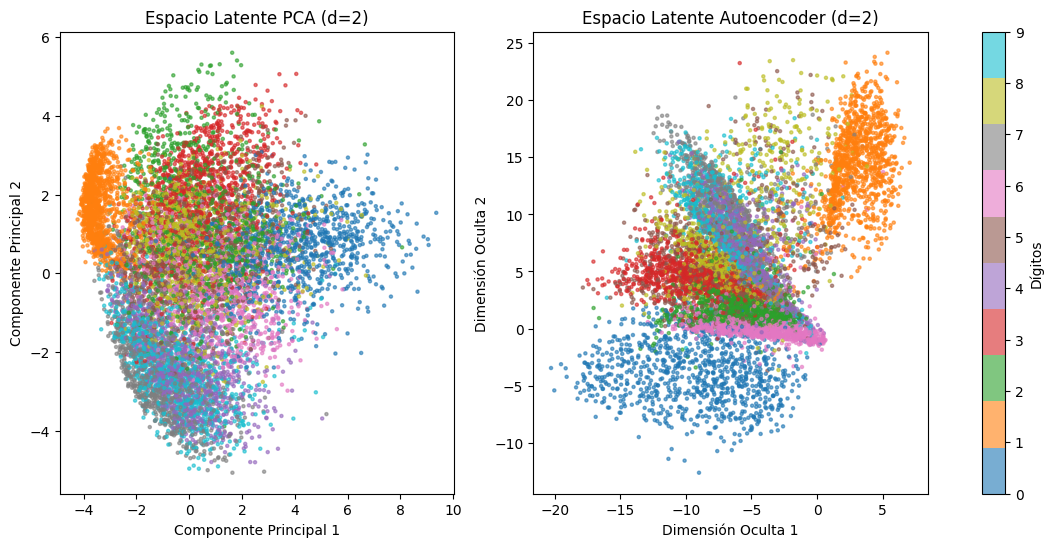

In [8]:
# ==========================================
# CELDA 3: FASE 2 - Espacio Latente 2D
# ==========================================
print("Generando visualizaciones del espacio latente (d=2)...")

# Extracción de latentes PCA
z_pca = pca_models[2].transform(X_test_full.numpy())

# Extracción de latentes Autoencoder
ae_d2 = models_ae[2]
ae_d2.eval()
with torch.no_grad():
    z_ae = ae_d2.encoder(X_test_full.to(device)).cpu().numpy()

# Visualización lado a lado
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.get_cmap('tab10')

# Plot PCA
sc_pca = axs[0].scatter(z_pca[:, 0], z_pca[:, 1], c=y_test_full, cmap=cmap, alpha=0.6, s=5)
axs[0].set_title('Espacio Latente PCA (d=2)')
axs[0].set_xlabel('Componente Principal 1')
axs[0].set_ylabel('Componente Principal 2')

# Plot AE
sc_ae = axs[1].scatter(z_ae[:, 0], z_ae[:, 1], c=y_test_full, cmap=cmap, alpha=0.6, s=5)
axs[1].set_title('Espacio Latente Autoencoder (d=2)')
axs[1].set_xlabel('Dimensión Oculta 1')
axs[1].set_ylabel('Dimensión Oculta 2')

fig.colorbar(sc_pca, ax=axs.ravel().tolist(), ticks=range(10), label='Dígitos')
plt.show()

# EXPLICACIÓN TEÓRICA (Comentario):
# El PCA es una transformación lineal que busca maximizar la varianza global, lo que resulta
# en clases fuertemente solapadas (baja separabilidad semántica) cuando d=2.
# El Autoencoder, al poseer funciones de activación no lineales (ReLU), puede "doblar" el espacio
# para agrupar los datos de manera más compleja. Generalmente, los clusters en el AE están mejor
# definidos topológicamente, facilitando tareas subyacentes de clasificación, a pesar de usar solo MSE.

Entrenando DeepJSCC de extremo a extremo a 10.0 dB (d=16)...
Entrenamiento DeepJSCC completado.



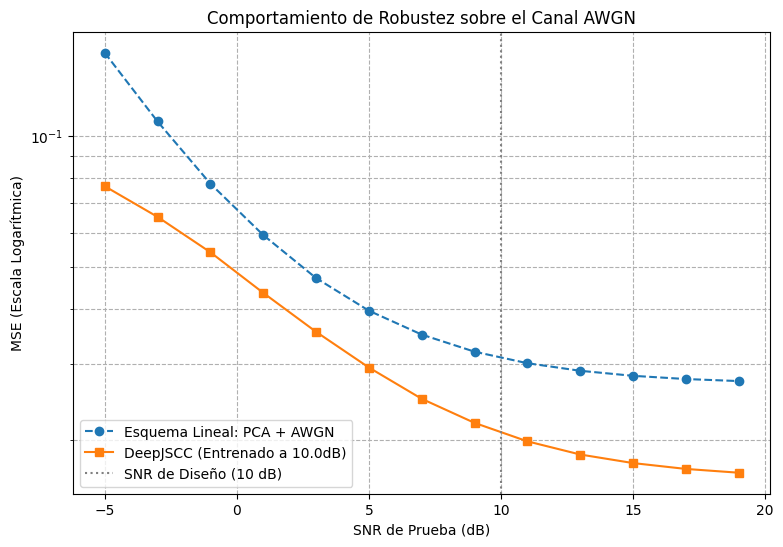

In [4]:
# ==========================================
# CELDA 4: FASE 3 - JSCC sobre Canal AWGN
# ==========================================

class AWGNChannel(nn.Module):
    """
    Simula un canal de comunicación físico con Ruido Gaussiano Blanco Aditivo (AWGN).
    Escala dinámicamente el ruido basándose en la potencia real de la señal de entrada
    para mantener la Relación Señal-Ruido (SNR) objetivo.
    """
    def __init__(self, snr_db):
        super(AWGNChannel, self).__init__()
        # Almacena la Relación Señal-a-Ruido (SNR) por defecto en decibelios (dB)
        self.snr_db = snr_db

    def forward(self, x, snr_db=None):
        # Permite sobrescribir la SNR durante la inferencia (útil para el barrido de ruido en la prueba)
        if snr_db is None:
            snr_db = self.snr_db

        # 1. Calcular la Potencia de la Señal
        # La potencia es la media de la amplitud al cuadrado de la señal.
        # En telecomunicaciones, Potencia = Voltaje^2 / Resistencia. Aquí asumimos Resistencia = 1.
        signal_power = torch.mean(x ** 2)

        # 2. Calcular la Varianza del Ruido
        # SNR(dB) = 10 * log10(Potencia_Señal / Potencia_Ruido)
        # Despejando: Potencia_Ruido = Potencia_Señal / 10^(SNR(dB) / 10)
        # En estadística, la "Potencia" de un ruido Gaussiano de media cero es exactamente su varianza (sigma^2).
        noise_var = signal_power / (10 ** (snr_db / 10.0))

        # 3. Generar el Ruido
        # torch.randn_like(x) genera ruido normal estándar (media = 0, varianza = 1).
        # Multiplicarlo por la desviación estándar (raíz cuadrada de la varianza) lo escala a la potencia deseada.
        noise = torch.randn_like(x) * torch.sqrt(noise_var)

        # 4. Transmitir por el Canal
        # El canal físico simplemente suma el ruido térmico generado a la señal original.
        return x + noise

class DeepJSCC(nn.Module):
    def __init__(self, latent_dim, P=1.0, snr_train=10.0):
        super(DeepJSCC, self).__init__()
        self.latent_dim = latent_dim
        self.P = P

        # Arquitectura idéntica a la Fase 1
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.channel = AWGNChannel(snr_train)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x, snr_db=None):
        # 1. Extracción de características
        z = self.encoder(x)

        # =======================================================================
        # 2. NORMALIZACIÓN DE POTENCIA: z_norm = sqrt(d * P) * (z / ||z||_2)
        # =======================================================================
        #
        # ¿POR QUÉ NORMALIZAR?
        # - Restricción física: Un transmisor real (móvil, antena) tiene un límite
        #   de potencia (batería, regulaciones). No puede transmitir con energía infinita.
        # - Evita "trampas" de la red neuronal: Si no limitamos la amplitud, el Autoencoder
        #   aprendería a escalar los valores al infinito para que el ruido del canal AWGN
        #   sea insignificante, en lugar de aprender a comprimir y proteger la información.
        #
        # ¿CÓMO FUNCIONA LA ECUACIÓN?
        # a) `norm = torch.norm(...)`: Calcula la longitud (norma Euclidiana L2) del vector.
        # b) `z / (norm + 1e-8)`: Proyecta el vector a una esfera de radio 1. Conserva la
        #    dirección semántica de los datos, pero resetea su magnitud. El 1e-8 evita
        #    colapsos matemáticos (división por cero) si la red escupe ceros absolutos.
        # c) `math.sqrt(d * P)`: Como la Potencia es proporcional a la Amplitud al cuadrado,
        #    para lograr una potencia objetivo, escalamos por su raíz cuadrada. Multiplicamos
        #    por `d` (dimensiones) para que la potencia *promedio* por cada dimensión sea `P`.
        norm = torch.norm(z, p=2, dim=1, keepdim=True)
        z_norm = math.sqrt(self.latent_dim * self.P) * (z / (norm + 1e-8))

        # 3. Transmisión por el canal AWGN
        z_noisy = self.channel(z_norm, snr_db)

        # 4. Decodificación
        x_hat = self.decoder(z_noisy)
        return x_hat

# ---------------------------------------------------------
# Entrenamiento del modelo JSCC (Extremo a Extremo) a 10 dB
# ---------------------------------------------------------
d_jscc = 16
snr_train_db = 10.0
print(f"Entrenando DeepJSCC de extremo a extremo a {snr_train_db} dB (d={d_jscc})...")

jscc_model = DeepJSCC(latent_dim=d_jscc, P=1.0, snr_train=snr_train_db).to(device)
criterion_jscc = nn.MSELoss()
optimizer_jscc = optim.Adam(jscc_model.parameters(), lr=1e-3)

jscc_model.train()
for epoch in range(10): # 10 épocas
    for data, _ in train_loader:
        data = data.to(device)
        optimizer_jscc.zero_grad()
        output = jscc_model(data)
        loss = criterion_jscc(output, data)
        loss.backward()
        optimizer_jscc.step()
print("Entrenamiento DeepJSCC completado.\n")

# ---------------------------------------------------------
# Evaluación de robustez (Barrido SNR: -5 dB a 20 dB)
# ---------------------------------------------------------
snr_test_range = np.arange(-5, 21, 2)
mse_jscc_list = []
mse_pca_awgn_list = []

# Extraer PCA para d=16
pca_16 = pca_models[16]
X_test_np = X_test_full.numpy()
Z_pca_test = pca_16.transform(X_test_np)

jscc_model.eval()
with torch.no_grad():
    test_tensor = X_test_full.to(device)

    for snr in snr_test_range:
        # --- Evaluación DeepJSCC ---
        # Forzamos el SNR de prueba sin reentrenar
        reconst_jscc = jscc_model(test_tensor, snr_db=snr)
        mse_j = criterion_jscc(reconst_jscc, test_tensor).item()
        mse_jscc_list.append(mse_j)

        # --- Evaluación Sistema Lineal (PCA + AWGN) ---
        # Calculamos la varianza del ruido equivalente según la potencia del PCA
        signal_power_pca = np.mean(Z_pca_test**2)
        noise_var_pca = signal_power_pca / (10 ** (snr / 10.0))
        noise_pca = np.random.normal(0, np.sqrt(noise_var_pca), Z_pca_test.shape)

        Z_pca_noisy = Z_pca_test + noise_pca
        X_pca_reconst = pca_16.inverse_transform(Z_pca_noisy)
        mse_p_awgn = np.mean((X_test_np - X_pca_reconst)**2)
        mse_pca_awgn_list.append(mse_p_awgn)

# Graficar robustez del sistema
plt.figure(figsize=(9, 6))
plt.plot(snr_test_range, mse_pca_awgn_list, 'o--', label='Esquema Lineal: PCA + AWGN')
plt.plot(snr_test_range, mse_jscc_list, 's-', label=f'DeepJSCC (Entrenado a {snr_train_db}dB)')
plt.axvline(x=snr_train_db, color='gray', linestyle=':', label='SNR de Diseño (10 dB)')
plt.yscale('log')
plt.xlabel('SNR de Prueba (dB)')
plt.ylabel('MSE (Escala Logarítmica)')
plt.title('Comportamiento de Robustez sobre el Canal AWGN')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

# EXPLICACIÓN TEÓRICA (Comentario):
# Observamos dos fenómenos clave de las comunicaciones digitales modernas:
# 1. "Cliff Effect" (Efecto Acantilado): Sistemas clásicos/lineales o separados tienden a fallar
#    catastróficamente cuando el canal cae por debajo de la calidad de diseño.
# 2. "Graceful Degradation" (Degradación Suave): DeepJSCC degrada la calidad de manera fluida y
#    continua. Incluso supera al método lineal a altos SNRs al haber optimizado de forma conjunta
#    la estructura semántica y la resistencia térmica del canal.

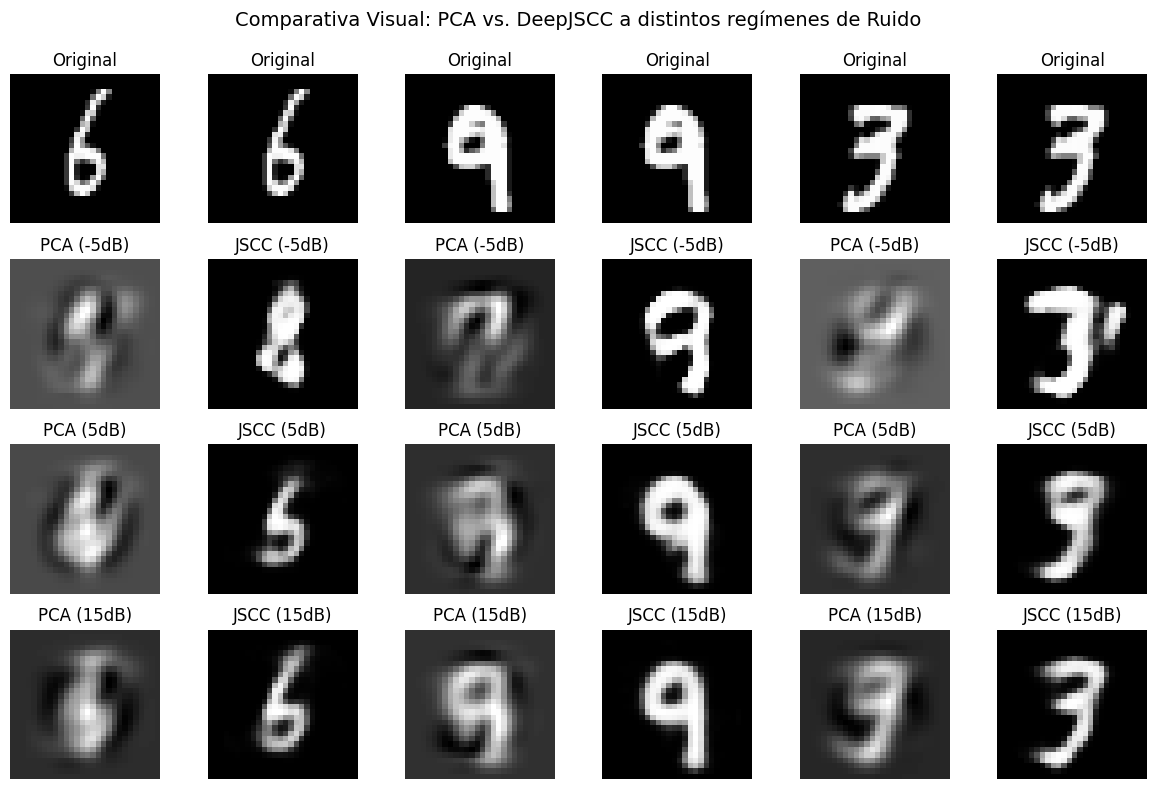

In [5]:
# ==========================================
# CELDA 5: Inspección Visual de Reconstrucciones
# ==========================================
snrs_to_plot = [-5, 5, 15]
num_images = 3

fig, axes = plt.subplots(len(snrs_to_plot) + 1, num_images * 2, figsize=(12, 8))
fig.suptitle("Comparativa Visual: PCA vs. DeepJSCC a distintos regímenes de Ruido", fontsize=14)

# Seleccionar 3 imágenes de prueba al azar
indices = np.random.choice(len(X_test_np), num_images, replace=False)
original_imgs = X_test_np[indices]
original_tensors = torch.tensor(original_imgs).to(device)
Z_pca_sample = pca_16.transform(original_imgs)

# Fila 1: Originales
for i in range(num_images):
    axes[0, i * 2].imshow(original_imgs[i].reshape(28, 28), cmap='gray')
    axes[0, i * 2].set_title("Original")
    axes[0, i * 2].axis('off')

    # Imagen dummy para mantener simetría en la cuadrícula
    axes[0, (i * 2) + 1].imshow(original_imgs[i].reshape(28, 28), cmap='gray')
    axes[0, (i * 2) + 1].set_title("Original")
    axes[0, (i * 2) + 1].axis('off')

# Filas subsecuentes: PCA y JSCC con ruido
jscc_model.eval()
with torch.no_grad():
    for row, snr in enumerate(snrs_to_plot, start=1):
        # Inferencias JSCC
        reconst_jscc = jscc_model(original_tensors, snr_db=snr).cpu().numpy()

        # Inferencias PCA
        sig_pow = np.mean(Z_pca_sample**2)
        n_var = sig_pow / (10 ** (snr / 10.0))
        Z_noisy = Z_pca_sample + np.random.normal(0, np.sqrt(n_var), Z_pca_sample.shape)
        reconst_pca = pca_16.inverse_transform(Z_noisy)

        for i in range(num_images):
            # Dibujar PCA
            axes[row, i * 2].imshow(reconst_pca[i].reshape(28, 28), cmap='gray')
            axes[row, i * 2].set_title(f"PCA ({snr}dB)")
            axes[row, i * 2].axis('off')

            # Dibujar JSCC
            axes[row, (i * 2) + 1].imshow(reconst_jscc[i].reshape(28, 28), cmap='gray')
            axes[row, (i * 2) + 1].set_title(f"JSCC ({snr}dB)")
            axes[row, (i * 2) + 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()